In [ ]:
import datajoint as dj

dj.config.load('/Users/neurozmar/Secrets/dj_local_conf_NDNF_behavior_HUN-REN_cloud.json')#dj_local_conf_NDNF_behavior_KOKI.json #dj_local_conf_NDNF_behavior_HUN
dj.conn() 
import os
import matplotlib
import matplotlib.pyplot as plt

from ndnf_pipeline import experiment, videography
from ndnf_pipeline.plot.videography_plots import load_trial_video_data, preview_last_frame, render_trial_video

matplotlib.rc('font', size=14)

## Parameters

In [52]:
subject_id       = 'M013'
session          = 7
block            = 1
trial_start      = 10     # block-relative: 0 = first trial of block
trial_end        = 18
camera_name      = 'SideCamera'

tail_s           = 5   # seconds of force tail to show per frame
force_axis_limit = 10.0  # (g) symmetric axis limits for both force plots
clim_pct         = (0, 95)  # (low%, high%) percentiles for video brightness
crop             = (150, 50, 0, 100)  # pixels to crop: (left, right, top, bottom)
pad_start        = 1.0   # seconds to include before first trial
pad_end          = 1.0   # seconds to include after last trial
playback_speed   = 1.0   # 1.0 = real time, 2.0 = 2× faster, 0.5 = half speed
output_dir       = '/Volumes/csoport16/temp/'#'/Users/neurozmar/Data/temp/'
output_path      = os.path.join(output_dir, f'{subject_id}_s{session}_b{block}_t{trial_start}-{trial_end}_{camera_name}.mp4')
video_fps        = 20    # framerate of saved file

lang             = 'en'  # 'en' or 'hu'

## Load data from DataJoint

In [ ]:
data = load_trial_video_data(subject_id, session, block, trial_start, trial_end, camera_name,
                              pad_start=pad_start, pad_end=pad_end)

print(f"Trials (session-absolute): {data['trials_needed']}")
print(f"Video file: {data['video_file_path']}")
print(f"Frames: {data['frame_abs_indices'][0]} – {data['frame_abs_indices'][-1]}  "
      f"({len(data['frame_abs_indices'])} frames, {data['t_video_end'] - data['t_video_start']:.1f}s)")

## Preview — last frame

In [ ]:
# --- preview: last frame ---
fig, last_frame, clims = preview_last_frame(data, crop, clim_pct=clim_pct, tail_s=tail_s,
                                             force_axis_limit=force_axis_limit, lang=lang)
plt.show()

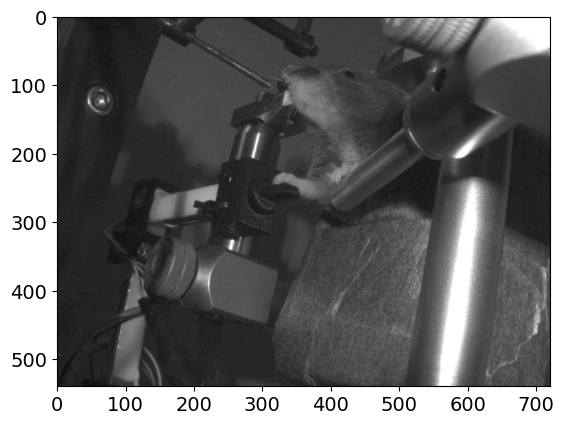

In [55]:
plt.imshow(last_frame)

## Make video
Run the cell below to confirm and render.

In [ ]:
proceed = input('Make video? (y/n): ').strip().lower()
if proceed != 'y':
    print('Cancelled.')
else:
    render_trial_video(data, output_path, video_fps=video_fps, playback_speed=playback_speed,
                        crop=crop, clims=clims, tail_s=tail_s, force_axis_limit=force_axis_limit, lang=lang)